In [1]:
import numpy as np
import pandas as pd
from tensorflow.keras.models import load_model
from keras.models import load_model
from PIL import Image
import cv2
import os
from PIL import Image
from pathlib import Path
from keras.models import Sequential
from keras.layers import Flatten, Dense
from keras.applications import VGG16
#from keras.preprocessing.image import ImageDataGenerator
from keras.utils import to_categorical
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.image import ImageDataGenerator

2026-03-17 08:54:09.224651: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1773737649.417666      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1773737649.470109      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1773737649.909965      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773737649.910008      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773737649.910011      55 computation_placer.cc:177] computation placer alr

In [2]:
import os
import pandas as pd

# Step 1: Load the CSV file containing labels
csv_file_path = '/kaggle/input/datasets/alifshahariar/utkface-dataset-face-aligned-and-labeled/utkface-aligned-labeled/labels.csv'  # Adjust this path
labels_df = pd.read_csv(csv_file_path)

# Step 2: Set the directory path to your UTKFace dataset
dataset_path = '/kaggle/input/datasets/alifshahariar/utkface-dataset-face-aligned-and-labeled/utkface-aligned-labeled/images'  # Adjust this path

# Step 3: Create a list of all image file paths in the dataset
image_files = [f for f in os.listdir(dataset_path) if f.endswith('.jpg')]

# Step 4: Map image names to their corresponding labels
# Assuming your CSV has columns like 'image_name' and 'age'
# Adjust the column names based on your actual CSV structure
labels_dict = {row['image']: row['age'] for _, row in labels_df.iterrows()}

# Step 5: Create a list to store the image paths and their corresponding labels
data = []

for img_name in image_files:
    if img_name in labels_dict:
        img_path = os.path.join(dataset_path, img_name)
        data.append({'image_path': img_path, 'label': labels_dict[img_name]})

# Step 6: Create a DataFrame
age_df = pd.DataFrame(data)

# Optionally, print the first few rows of the DataFrame to verify
print(age_df.head())

                                          image_path  label
0  /kaggle/input/datasets/alifshahariar/utkface-d...     26
1  /kaggle/input/datasets/alifshahariar/utkface-d...     22
2  /kaggle/input/datasets/alifshahariar/utkface-d...     21
3  /kaggle/input/datasets/alifshahariar/utkface-d...     28
4  /kaggle/input/datasets/alifshahariar/utkface-d...     17


In [3]:
# Create age bins
def age_to_bin(age):
    if age < 11:
        return 0
    elif age < 21:
        return 1
    elif age < 31:
        return 2
    elif age < 41:
        return 3
    elif age < 51:
        return 4
    elif age < 61:
        return 5
    elif age < 71:
        return 6
    else:
        return 7


In [4]:
age_df["age_bin"] = age_df["label"].apply(age_to_bin)

In [6]:
print(age_df)

                                              image_path  label  age_bin
0      /kaggle/input/datasets/alifshahariar/utkface-d...     26        2
1      /kaggle/input/datasets/alifshahariar/utkface-d...     22        2
2      /kaggle/input/datasets/alifshahariar/utkface-d...     21        2
3      /kaggle/input/datasets/alifshahariar/utkface-d...     28        2
4      /kaggle/input/datasets/alifshahariar/utkface-d...     17        1
...                                                  ...    ...      ...
23700  /kaggle/input/datasets/alifshahariar/utkface-d...     41        4
23701  /kaggle/input/datasets/alifshahariar/utkface-d...     42        4
23702  /kaggle/input/datasets/alifshahariar/utkface-d...      2        0
23703  /kaggle/input/datasets/alifshahariar/utkface-d...     65        6
23704  /kaggle/input/datasets/alifshahariar/utkface-d...     66        6

[23705 rows x 3 columns]


In [8]:
df = age_df

In [9]:
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

class UTKFaceDataset(Dataset):
    def __init__(self, dataframe, dataset_path, transform=None):
        self.df = dataframe
        self.dataset_path = dataset_path
        self.transform = transform
    
    def __len__(self):
        return len(self.df)
    
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_path = os.path.join(self.dataset_path, row['image_path'])
        
        try:
            image = Image.open(img_path).convert('RGB')
        except:
            # Handle corrupted images
            return None
        
        if self.transform:
            image = self.transform(image)
        
        age_bin = torch.tensor(row['age_bin'], dtype=torch.long)
        
        return image, age_bin

# Define transforms
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                        std=[0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                        std=[0.229, 0.224, 0.225])
])

# Split dataset (80-20 train-val)
from sklearn.model_selection import train_test_split
train_df, val_df = train_test_split(df, test_size=0.2, random_state=42, stratify=df['age_bin'])

train_dataset = UTKFaceDataset(train_df, dataset_path, train_transform)
val_dataset = UTKFaceDataset(val_df, dataset_path, val_transform)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True, num_workers=4)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False, num_workers=4)


In [10]:
import torch.nn as nn
from torchvision import models

class AgeClassifier(nn.Module):
    def __init__(self, num_classes=8):
        super(AgeClassifier, self).__init__()
        # Load pre-trained ResNet50
        self.backbone = models.resnet50(pretrained=True)
        
        # Replace the final classification layer
        num_features = self.backbone.fc.in_features
        self.backbone.fc = nn.Linear(num_features, num_classes)
    
    def forward(self, x):
        return self.backbone(x)

model = AgeClassifier(num_classes=8)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = model.to(device)
print(f"Model loaded on {device}")


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 190MB/s]


Model loaded on cuda


In [11]:
import torch.optim as optim
from torch.optim.lr_scheduler import ReduceLROnPlateau

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
scheduler = ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=3)

def train_epoch(model, train_loader, criterion, optimizer, device):
    model.train()
    total_loss = 0
    correct = 0
    total = 0
    
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
    
    avg_loss = total_loss / len(train_loader)
    accuracy = 100 * correct / total
    return avg_loss, accuracy

def validate(model, val_loader, criterion, device):
    model.eval()
    total_loss = 0
    correct = 0
    total = 0
    
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            total_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    
    avg_loss = total_loss / len(val_loader)
    accuracy = 100 * correct / total
    return avg_loss, accuracy

# Training loop
num_epochs = 20
best_val_acc = 0

for epoch in range(num_epochs):
    train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, device)
    val_loss, val_acc = validate(model, val_loader, criterion, device)
    
    scheduler.step(val_acc)
    
    print(f"Epoch [{epoch+1}/{num_epochs}]")
    print(f"  Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}%")
    print(f"  Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.2f}%")
    
    # Save best model
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), 'best_age_classifier.pth')
        print(f"  ✓ Best model saved (Val Acc: {val_acc:.2f}%)")


Epoch [1/20]
  Train Loss: 1.3053, Train Acc: 49.85%
  Val Loss: 1.2902, Val Acc: 45.56%
  ✓ Best model saved (Val Acc: 45.56%)
Epoch [2/20]
  Train Loss: 1.1293, Train Acc: 54.67%
  Val Loss: 1.3297, Val Acc: 44.02%
Epoch [3/20]
  Train Loss: 1.0725, Train Acc: 56.45%
  Val Loss: 1.1579, Val Acc: 54.31%
  ✓ Best model saved (Val Acc: 54.31%)
Epoch [4/20]
  Train Loss: 1.0311, Train Acc: 57.65%
  Val Loss: 1.0644, Val Acc: 55.92%
  ✓ Best model saved (Val Acc: 55.92%)
Epoch [5/20]
  Train Loss: 1.0058, Train Acc: 58.86%
  Val Loss: 0.9873, Val Acc: 59.12%
  ✓ Best model saved (Val Acc: 59.12%)
Epoch [6/20]
  Train Loss: 0.9876, Train Acc: 59.51%
  Val Loss: 0.9864, Val Acc: 58.07%
Epoch [7/20]
  Train Loss: 0.9574, Train Acc: 60.10%
  Val Loss: 0.9861, Val Acc: 58.26%
Epoch [8/20]
  Train Loss: 0.9537, Train Acc: 60.18%
  Val Loss: 1.1108, Val Acc: 55.11%
Epoch [9/20]
  Train Loss: 0.9349, Train Acc: 61.03%
  Val Loss: 1.0017, Val Acc: 59.57%
  ✓ Best model saved (Val Acc: 59.57%)
Epoc

In [16]:
import matplotlib.pyplot as plt


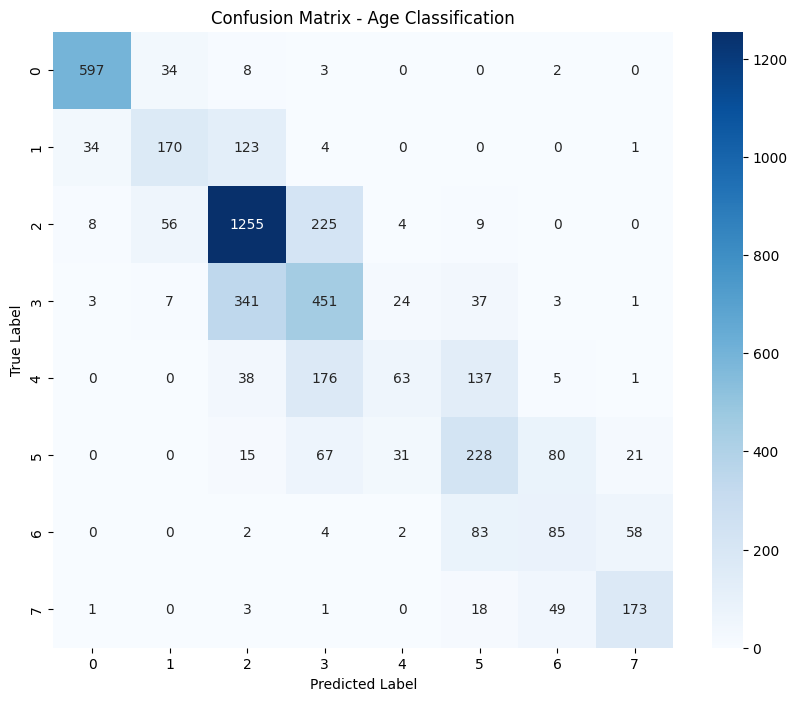

              precision    recall  f1-score   support

        0-10       0.93      0.93      0.93       644
       11-20       0.64      0.51      0.57       332
       21-30       0.70      0.81      0.75      1557
       31-40       0.48      0.52      0.50       867
       41-50       0.51      0.15      0.23       420
       51-60       0.45      0.52      0.48       442
       61-70       0.38      0.36      0.37       234
         71+       0.68      0.71      0.69       245

    accuracy                           0.64      4741
   macro avg       0.60      0.56      0.57      4741
weighted avg       0.63      0.64      0.62      4741



In [17]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

# Load best model
model.load_state_dict(torch.load('best_age_classifier.pth'))

# Get predictions on validation set
all_preds = []
all_labels = []

model.eval()
with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs.data, 1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.numpy())

# Confusion matrix
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - Age Classification')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

# Classification report
print(classification_report(all_labels, all_preds, 
                          target_names=['0-10', '11-20', '21-30', '31-40', 
                                       '41-50', '51-60', '61-70', '71+']))


In [20]:
import torch
import torch.nn as nn
from torchvision import models, transforms
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

# Define the model architecture
class AgeClassifier(nn.Module):
    def __init__(self, num_classes=8):
        super(AgeClassifier, self).__init__()
        self.backbone = models.resnet50(pretrained=False)
        in_features = self.backbone.fc.in_features
        self.backbone.fc = nn.Linear(in_features, num_classes)
    
    def forward(self, x):
        return self.backbone(x)

# Load the trained model
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = AgeClassifier(num_classes=8)
model.load_state_dict(torch.load('/kaggle/working/best_age_classifier.pth', map_location=device))
model.to(device)
model.eval()

print(f"Model loaded successfully on {device}")


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


Model loaded successfully on cuda


In [21]:
# Define preprocessing (must match your training preprocessing)
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                        std=[0.229, 0.224, 0.225])
])

age_groups = ['0-10', '11-20', '21-30', '31-40', '41-50', '51-60', '61-70', '71+']


In [26]:
def predict_age_single(image_path):
    """Predict age group for a single image"""
    image = Image.open(image_path).convert('RGB')
    image_tensor = transform(image).unsqueeze(0).to(device)
    
    with torch.no_grad():
        outputs = model(image_tensor)
        probabilities = torch.softmax(outputs, dim=1)[0].cpu().numpy()
        predicted_class = np.argmax(probabilities)
    
    return age_groups[predicted_class], probabilities

# Test
predicted_age, probs = predict_age_single('/kaggle/input/models/adityamodi20/face-images/tflite/default/1/pexels-kingdb-14398138.jpg')
print(f"Predicted Age Group: {predicted_age}")
print(f"Confidence: {probs[age_groups.index(predicted_age)]:.2%}")
print(f"\nAll Probabilities:")
for age_group, prob in zip(age_groups, probs):
    print(f"  {age_group}: {prob:.2%}")


Predicted Age Group: 11-20
Confidence: 77.63%

All Probabilities:
  0-10: 2.98%
  11-20: 77.63%
  21-30: 7.06%
  31-40: 0.78%
  41-50: 1.62%
  51-60: 2.03%
  61-70: 1.44%
  71+: 6.46%


In [27]:
import os
from pathlib import Path

def test_folder(folder_path):
    """Test all images in a folder"""
    image_extensions = {'.jpg', '.jpeg', '.png', '.bmp', '.gif'}
    image_paths = [str(p) for p in Path(folder_path).rglob('*') 
                   if p.suffix.lower() in image_extensions]
    
    print(f"Found {len(image_paths)} images")
    
    results = []
    for image_path in image_paths[:20]:  # Test first 20 images
        predicted_age, probs = predict_age_single(image_path)
        results.append({
            'image': os.path.basename(image_path),
            'predicted_age': predicted_age,
            'confidence': probs[age_groups.index(predicted_age)]
        })
    
    # Display results
    for result in results:
        print(f"{result['image']}: {result['predicted_age']} ({result['confidence']:.2%})")

# Example usage
test_folder('/kaggle/input/models/adityamodi20/face-images/tflite/default/1')


Found 8 images
pexels-faza-zeed-162810616-13624761.jpg: 0-10 (50.65%)
pexels-italo-melo-881954-2379005.jpg: 11-20 (36.59%)
pexels-adil-asainov-912950932-27967698.jpg: 0-10 (30.99%)
pexels-heitorverdifotos-2169434.jpg: 71+ (68.77%)
pexels-minan1398-1066109.jpg: 71+ (99.45%)
pexels-sidali-12712257.jpg: 21-30 (39.81%)
pexels-kingdb-14398138.jpg: 11-20 (77.63%)
pexels-luciano-pacheco-44399195-7864440.jpg: 71+ (92.08%)


Found 24 images

[ 1/24] elderly_man_happy_1.jpg             | True: 71+      | Pred: 71+      | 99.82% | ✓ CORRECT
[ 2/24] elderly_man_happy_2.jpg             | True: 71+      | Pred: 71+      | 99.13% | ✓ CORRECT
[ 3/24] elderly_man_happy_3.jpg             | True: 71+      | Pred: 71+      | 99.25% | ✓ CORRECT
[ 4/24] elderly_man_sad_1.jpg               | True: 71+      | Pred: 71+      | 85.64% | ✓ CORRECT
[ 5/24] elderly_man_sad_2.jpg               | True: 71+      | Pred: 71+      | 98.94% | ✓ CORRECT
[ 6/24] elderly_man_sad_3.jpg               | True: 71+      | Pred: 71+      | 99.70% | ✓ CORRECT
[ 7/24] elderly_woman_happy_1.jpg           | True: 71+      | Pred: 71+      | 98.60% | ✓ CORRECT
[ 8/24] elderly_woman_happy_2.jpg           | True: 71+      | Pred: 71+      | 58.73% | ✓ CORRECT
[ 9/24] elderly_woman_happy_3.jpg           | True: 71+      | Pred: 71+      | 86.53% | ✓ CORRECT
[10/24] elderly_woman_sad_1.jpg             | True: 71+      | Pred: 71+      | 60.91% | ✓ C

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:2687: UserWarning: labels size, 4, does not match size of target_names, 8
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to con

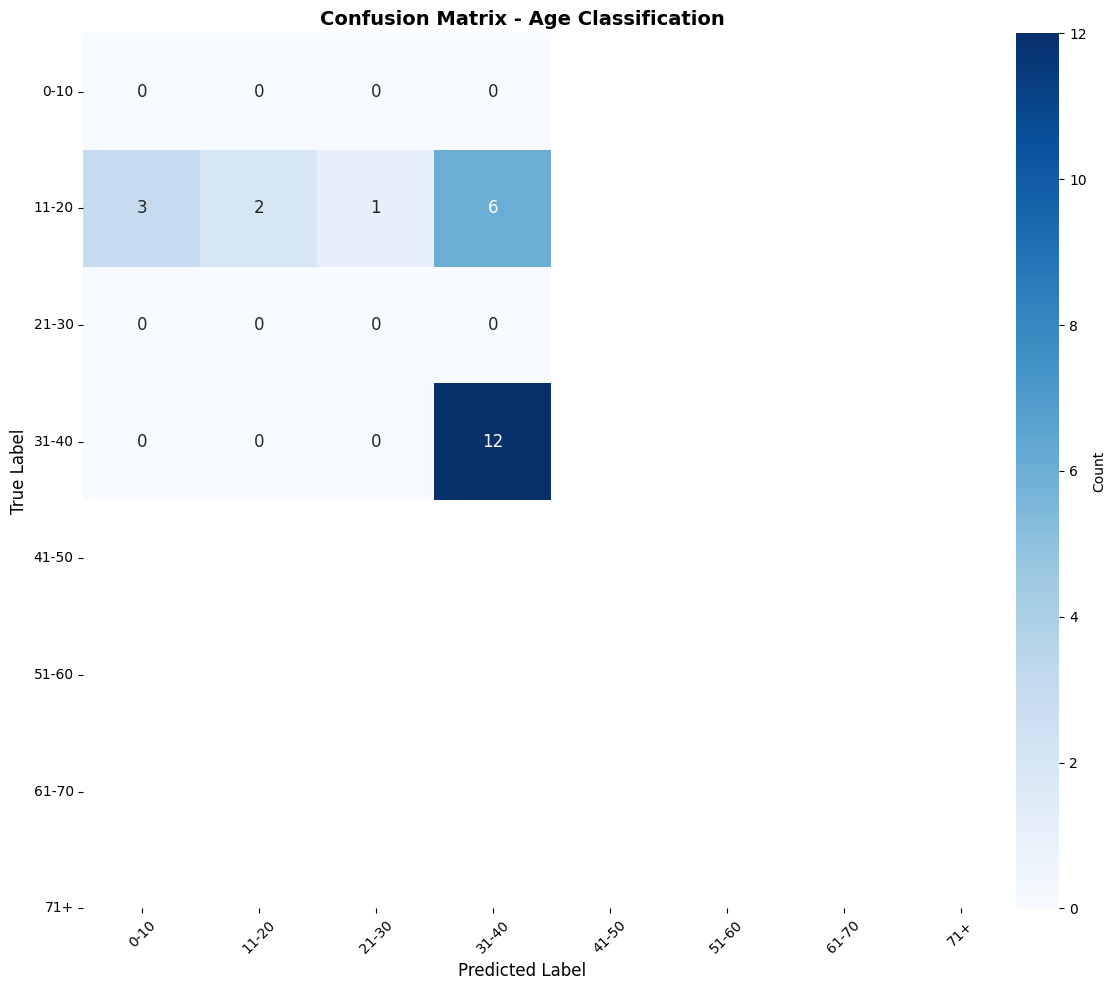


ACCURACY PER AGE GROUP
  21-30: 16.67% (2/12)
  71+: 100.00% (12/12)

RESULTS BY CATEGORY (ELDERLY vs YOUNG)
Elderly: 12/12 correct (100.00%)
Young:   2/12 correct (16.67%)

DETAILED TEST RESULTS
Image                               True       Predicted  Confidence   Status    
--------------------------------------------------------------------------------
elderly_man_happy_1.jpg             71+        71+        99.82%       ✓         
elderly_man_happy_2.jpg             71+        71+        99.13%       ✓         
elderly_man_happy_3.jpg             71+        71+        99.25%       ✓         
elderly_man_sad_1.jpg               71+        71+        85.64%       ✓         
elderly_man_sad_2.jpg               71+        71+        98.94%       ✓         
elderly_man_sad_3.jpg               71+        71+        99.70%       ✓         
elderly_woman_happy_1.jpg           71+        71+        98.60%       ✓         
elderly_woman_happy_2.jpg           71+        71+        58.73%  

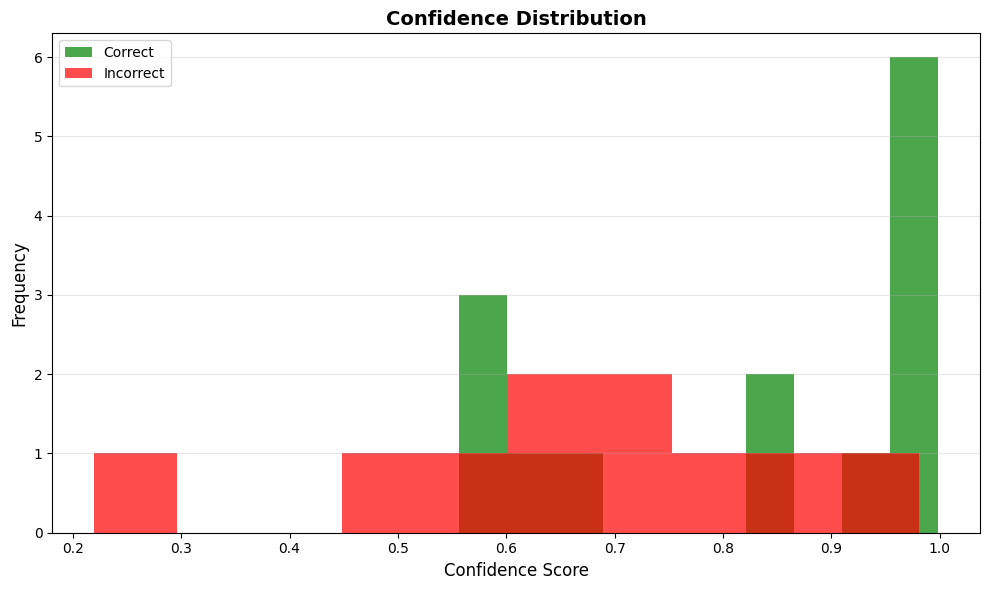

In [38]:
import os
from pathlib import Path
import numpy as np
import torch
from PIL import Image
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt

# Define age group mappings
label_mapping = {
    'child': 0,        # 0-10
    'teen': 1,         # 11-20
    'adult': 2,        # 21-30
    'middle': 3,       # 31-40
    'mature': 4,       # 41-50
    'senior': 5,       # 51-60
    'older': 6,        # 61-70
    'elderly': 7,      # 71+
    
}

age_groups = ['0-10', '11-20', '21-30', '31-40', '41-50', '51-60', '61-70', '71+']

def extract_label_from_filename(filename):
    """
    Extract age group label from filename
    Examples:
    - 'elderly_man_happy_1.jpg' -> 7 (71+)
    - 'young_woman_sad_2.jpg' -> 1 (11-20)
    """
    filename_lower = filename.lower()


# here we are only targeting adult and elderly image from the folder.

# Check for each age group keyword
    if 'young' in filename_lower:
        return 2, 'adult'
    elif 'teen' in filename_lower:
        return 1, 'teen'
    elif 'adult' in filename_lower:
        return 2, 'adult'
    elif 'middle' in filename_lower:
        return 3, 'middle'
    elif 'mature' in filename_lower:
        return 4, 'mature'
    elif 'senior' in filename_lower:
        return 5, 'senior'
    elif 'older' in filename_lower:
        return 6, 'older'
    elif 'elderly' in filename_lower:
        return 7, 'elderly'
    else:
        print(f"Warning: Could not extract label from '{filename}'")
        return None, None
    


def test_folder_with_labels(folder_path):
    """
    Test all images in a folder and calculate metrics
    """
    image_extensions = {'.jpg', '.jpeg', '.png', '.bmp', '.gif'}
    image_paths = sorted([p for p in Path(folder_path).rglob('*') 
                         if p.suffix.lower() in image_extensions])
    
    print(f"Found {len(image_paths)} images\n")
    print("="*80)
    
    all_preds = []
    all_labels = []
    results = []
    
    # Process each image
    for idx, image_path in enumerate(image_paths):
        filename = image_path.name
        
        # Extract true label from filename
        true_label_idx, label_name = extract_label_from_filename(filename)
        
        if true_label_idx is None:
            print(f"Skipping {filename} - could not extract label")
            continue
        
        # Predict age group
        try:
            image = Image.open(image_path).convert('RGB')
            image_tensor = transform(image).unsqueeze(0).to(device)
            
            with torch.no_grad():
                outputs = model(image_tensor)
                probabilities = torch.softmax(outputs, dim=1)[0].cpu().numpy()
                predicted_class = np.argmax(probabilities)
            
            confidence = probabilities[predicted_class]
            is_correct = predicted_class == true_label_idx
            
            all_preds.append(predicted_class)
            all_labels.append(true_label_idx)
            
            results.append({
                'filename': filename,
                'true_label': age_groups[true_label_idx],
                'predicted_label': age_groups[predicted_class],
                'confidence': confidence,
                'correct': is_correct,
                'true_category': label_name
            })
            
            status = "✓ CORRECT" if is_correct else "✗ WRONG"
            print(f"[{idx+1:2d}/{len(image_paths)}] {filename:<35} | True: {age_groups[true_label_idx]:<8} | Pred: {age_groups[predicted_class]:<8} | {confidence:>6.2%} | {status}")
            
        except Exception as e:
            print(f"Error processing {filename}: {e}")
            continue
    
    if len(all_preds) == 0:
        print("No images were successfully processed!")
        return
    
    all_preds = np.array(all_preds)
    all_labels = np.array(all_labels)
    
    # Calculate metrics
    accuracy = accuracy_score(all_labels, all_preds)
    correct_count = np.sum(all_preds == all_labels)
    
    print("\n" + "="*80)
    print("OVERALL METRICS")
    print("="*80)
    print(f"Accuracy: {accuracy:.2%} ({correct_count}/{len(all_preds)} correct)")
    print(f"Total Images Tested: {len(all_preds)}\n")
    
    # Classification report
    print("="*80)
    print("DETAILED CLASSIFICATION REPORT")
    print("="*80)
    
    # Get unique classes that actually appear in labels and predictions
    unique_classes = sorted(np.unique(np.concatenate([all_labels, all_preds])))
    class_names = [age_groups[i] for i in unique_classes]
    
    print(classification_report(all_labels, all_preds,labels=unique_classes, target_names=age_groups))
    
    # Confusion matrix visualization
    cm = confusion_matrix(all_labels, all_preds, labels=unique_classes)
    plt.figure(figsize=(12, 10))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=age_groups, yticklabels=age_groups,
                cbar_kws={'label': 'Count'}, annot_kws={'size': 12})
    plt.title('Confusion Matrix - Age Classification', fontsize=14, fontweight='bold')
    plt.ylabel('True Label', fontsize=12)
    plt.xlabel('Predicted Label', fontsize=12)
    plt.xticks(rotation=45)
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()


        # Per-class accuracy - FIXED: Only show classes that appear
    print("\n" + "="*80)
    print("ACCURACY PER AGE GROUP")
    print("="*80)
    for i, class_idx in enumerate(unique_classes):
        if cm.sum(axis=1)[i] > 0:
            acc = cm.diagonal()[i] / cm.sum(axis=1)[i]
            count = int(cm.diagonal()[i])
            total = int(cm.sum(axis=1)[i])
            print(f"  {age_groups[class_idx]}: {acc:.2%} ({count}/{total})")


    # Results by category (elderly vs young)
    print("\n" + "="*80)
    print("RESULTS BY CATEGORY (ELDERLY vs YOUNG)")
    print("="*80)
    
    elderly_correct = sum(1 for r in results if r['true_category'] == 'elderly' and r['correct'])
    elderly_total = sum(1 for r in results if r['true_category'] == 'elderly')
    young_correct = sum(1 for r in results if r['true_category'] == 'adult' and r['correct'])
    young_total = sum(1 for r in results if r['true_category'] == 'adult')
    
    print(f"Elderly: {elderly_correct}/{elderly_total} correct ({elderly_correct/elderly_total*100:.2f}%)")
    print(f"Young:   {young_correct}/{young_total} correct ({young_correct/young_total*100:.2f}%)")
    
    # Detailed results table
    print("\n" + "="*80)
    print("DETAILED TEST RESULTS")
    print("="*80)
    print(f"{'Image':<35} {'True':<10} {'Predicted':<10} {'Confidence':<12} {'Status':<10}")
    print("-"*80)
    for result in results:
        status = "✓" if result['correct'] else "✗"
        print(f"{result['filename']:<35} {result['true_label']:<10} {result['predicted_label']:<10} {result['confidence']:<12.2%} {status:<10}")
    
    # Summary statistics
    print("\n" + "="*80)
    print("SUMMARY STATISTICS")
    print("="*80)
    confidences = [r['confidence'] for r in results]
    print(f"Average Confidence: {np.mean(confidences):.2%}")
    print(f"Min Confidence: {np.min(confidences):.2%}")
    print(f"Max Confidence: {np.max(confidences):.2%}")
    
    # Plot confidence distribution
    plt.figure(figsize=(10, 6))
    plt.hist([r['confidence'] for r in results if r['correct']], bins=10, alpha=0.7, label='Correct', color='green')
    plt.hist([r['confidence'] for r in results if not r['correct']], bins=10, alpha=0.7, label='Incorrect', color='red')
    plt.xlabel('Confidence Score', fontsize=12)
    plt.ylabel('Frequency', fontsize=12)
    plt.title('Confidence Distribution', fontsize=14, fontweight='bold')
    plt.legend()
    plt.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    return results, all_labels, all_preds

# Run the test
results, true_labels, predictions = test_folder_with_labels('/kaggle/input/models/adityamodi20/testing-image/tflite/default/1/hualcosa DLBAIPEAI01_edge_ai main evaluation_images')
